In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q -U transformers accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 111.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 39.9 MB/s eta 0:00:00


In [3]:
import transformers
import accelerate

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 5.17.0
Accelerate: 1.15.0


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
IMAGE_PATH = "/content/drive/MyDrive/Meenakshi /Dataset/handwriteen/scraphand3.png"

In [6]:
import os
import json
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

Image size: (218, 123)


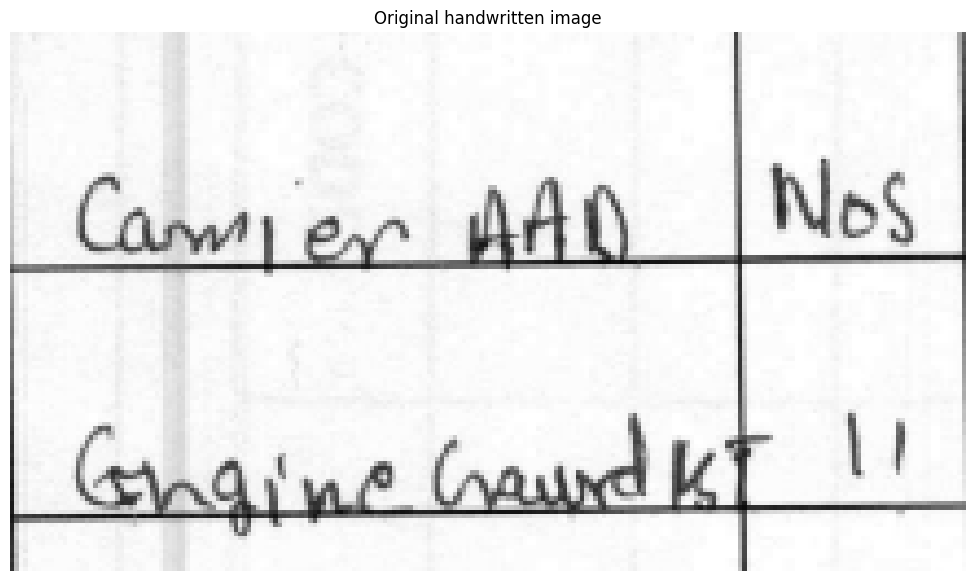

In [7]:
image = Image.open(IMAGE_PATH).convert("RGB")

print("Image size:", image.size)

plt.figure(figsize=(14, 7))
plt.imshow(image)
plt.axis("off")
plt.title("Original handwritten image")
plt.show()

In [8]:
def preprocess_handwriting(image):
    img = np.array(image)

    # RGB -> grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Upscale
    scale = 3
    upscaled = cv2.resize(
        gray,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC
    )

    # Improve local contrast
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(upscaled)

    # Light denoising
    denoised = cv2.fastNlMeansDenoising(
        enhanced,
        None,
        h=5,
        templateWindowSize=7,
        searchWindowSize=21
    )

    return denoised

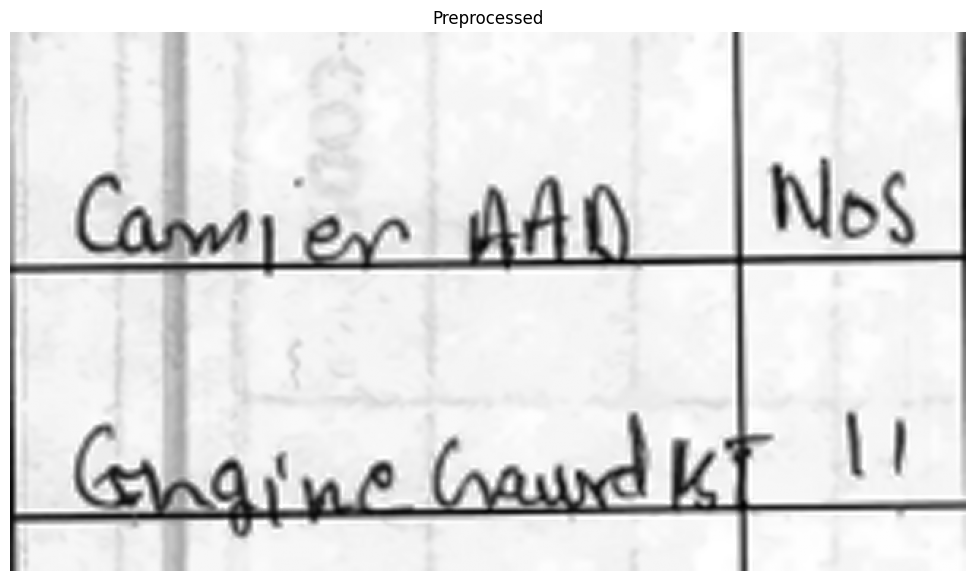

In [9]:
processed = preprocess_handwriting(image)

plt.figure(figsize=(14, 7))
plt.imshow(processed, cmap="gray")
plt.axis("off")
plt.title("Preprocessed")
plt.show()

In [10]:
def detect_table_lines(image):
    gray = cv2.cvtColor(
        np.array(image),
        cv2.COLOR_RGB2GRAY
    )

    # Binary image
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        10
    )

    # Horizontal lines
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (max(20, image.width // 10), 1)
    )

    horizontal = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # Vertical lines
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, max(20, image.height // 10))
    )

    vertical = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    return horizontal, vertical, binary

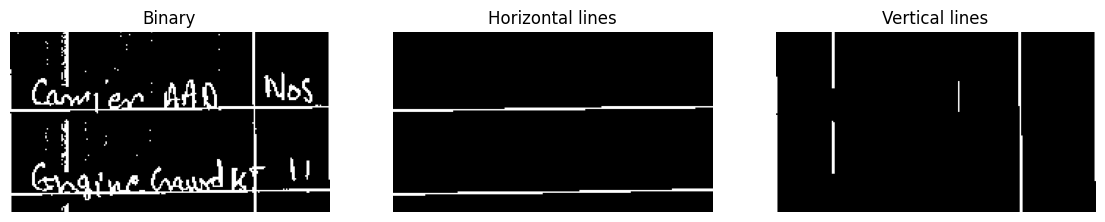

In [11]:
horizontal, vertical, binary = detect_table_lines(image)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(horizontal, cmap="gray")
plt.title("Horizontal lines")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(vertical, cmap="gray")
plt.title("Vertical lines")
plt.axis("off")

plt.show()

In [12]:
def remove_table_lines(image):
    img = np.array(image.convert("RGB"))

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        10
    )

    # Horizontal lines
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (max(15, image.width // 12), 1)
    )

    horizontal = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # Vertical lines
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, max(15, image.height // 12))
    )

    vertical = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    lines = cv2.bitwise_or(
        horizontal,
        vertical
    )

    # Remove detected lines
    cleaned = cv2.subtract(
        binary,
        lines
    )

    # Convert back to black text on white background
    cleaned = 255 - cleaned

    return Image.fromarray(cleaned)

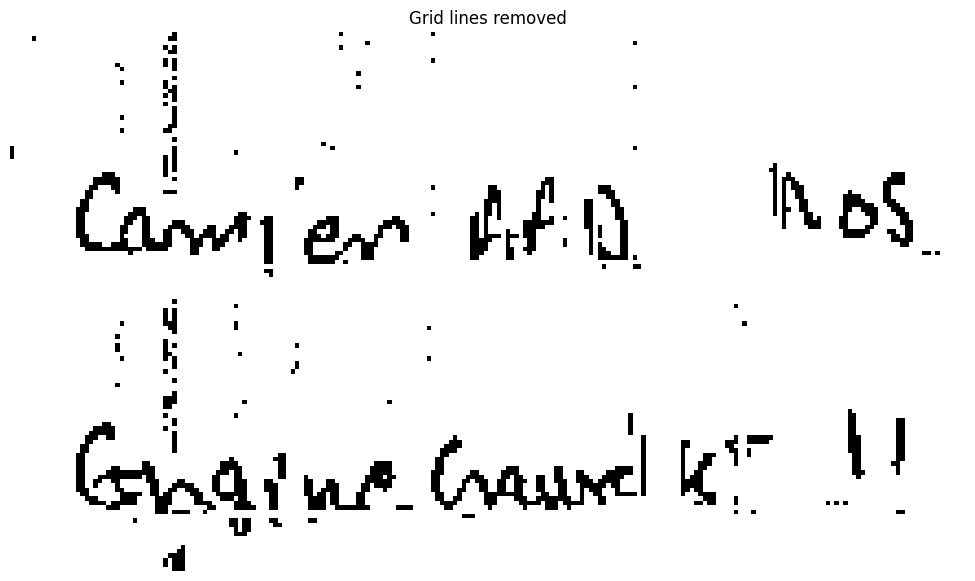

In [13]:
cleaned = remove_table_lines(image)

plt.figure(figsize=(14, 7))
plt.imshow(cleaned, cmap="gray")
plt.axis("off")
plt.title("Grid lines removed")
plt.show()

In [14]:
MODEL_ID = "stepfun-ai/GOT-OCR-2.0-hf"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading model...")

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    use_fast=True
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

print("Model loaded")

Loading model...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

Model loaded


In [15]:
def got_ocr(
    image,
    max_new_tokens=512,
    crop_to_patches=False,
    max_patches=3
):
    """
    Run GOT-OCR 2.0 on an image.
    """

    if isinstance(image, np.ndarray):
        if len(image.shape) == 2:
            image = Image.fromarray(image)
        else:
            image = Image.fromarray(
                cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            )

    image = image.convert("RGB")

    processor_kwargs = {
        "return_tensors": "pt"
    }

    if crop_to_patches:
        processor_kwargs["crop_to_patches"] = True
        processor_kwargs["max_patches"] = max_patches

    inputs = processor(
        image,
        **processor_kwargs
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            do_sample=False,
            tokenizer=processor.tokenizer,
            stop_strings="<|im_end|>",
            max_new_tokens=max_new_tokens
        )

    input_length = inputs["input_ids"].shape[1]

    generated_text = processor.decode(
        generated_ids[0][input_length:],
        skip_special_tokens=True
    )

    return generated_text.strip()

In [16]:
result_full = got_ocr(
    image,
    max_new_tokens=512,
    crop_to_patches=True,
    max_patches=3
)

print("========== GOT OCR RESULT ==========")
print(result_full)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


========== GOT OCR RESULT ==========
Cawjer AAD


In [45]:
# Format:
# (x1, y1, x2, y2)

boxes = {
    "row1_wld":     (0, 0, 170, 60),
    "row1_carrier": (170, 0, 303, 60),

    "row2_wld":     (0, 60, 170, 120),
    "row2_carrier": (170, 60, 303, 120),

   
}

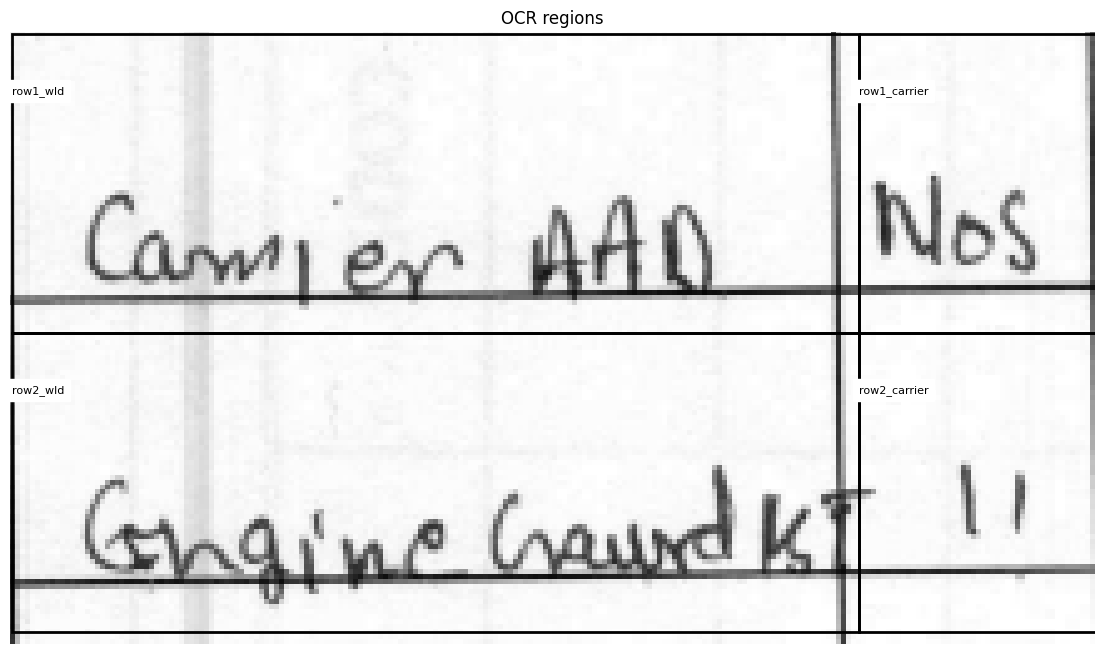

In [46]:
img_np = np.array(image)

plt.figure(figsize=(14, 8))
plt.imshow(img_np)

for name, (x1, y1, x2, y2) in boxes.items():

    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )

    plt.gca().add_patch(rectangle)

    plt.text(
        x1,
        y1 + 12,
        name,
        fontsize=8,
        backgroundcolor="white"
    )

plt.axis("off")
plt.title("OCR regions")
plt.show()

In [47]:
def crop_box(image, box, padding=3):

    x1, y1, x2, y2 = box

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)

    x2 = min(image.width, x2 + padding)
    y2 = min(image.height, y2 + padding)

    return image.crop((x1, y1, x2, y2))

In [48]:
cell_images = {}

for name, box in boxes.items():

    crop = crop_box(
        image,
        box,
        padding=3
    )

    cell_images[name] = crop

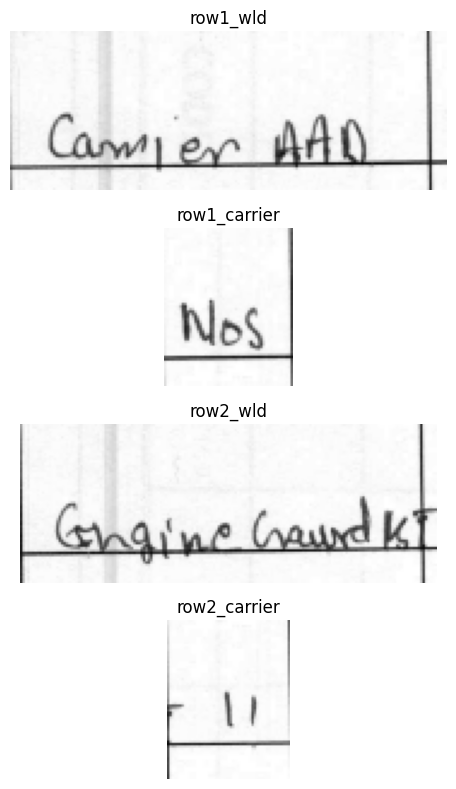

In [49]:
n = len(cell_images)

fig, axes = plt.subplots(
    n,
    1,
    figsize=(12, n * 2)
)

if n == 1:
    axes = [axes]

for ax, (name, crop) in zip(
    axes,
    cell_images.items()
):

    ax.imshow(crop)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [50]:
clean_cells = {}

for name, crop in cell_images.items():

    clean = remove_table_lines(crop)

    clean_cells[name] = clean

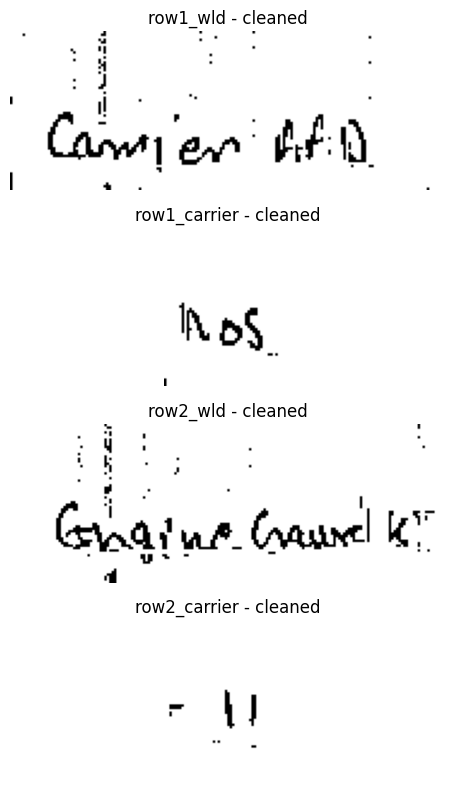

In [51]:
fig, axes = plt.subplots(
    len(clean_cells),
    1,
    figsize=(12, len(clean_cells) * 2)
)

if len(clean_cells) == 1:
    axes = [axes]

for ax, (name, crop) in zip(
    axes,
    clean_cells.items()
):

    ax.imshow(crop, cmap="gray")
    ax.set_title(f"{name} - cleaned")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [52]:
results = {}

for name, crop in clean_cells.items():

    print("=" * 70)
    print("Processing:", name)

    text = got_ocr(
        crop,
        max_new_tokens=128,
        crop_to_patches=False
    )

    results[name] = text

    print("GOT:", repr(text))

Processing: row1_wld
GOT: ':  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :  :'
Processing: row1_carrier
GOT: '1#DS.'
Processing: row2_wld
GOT: ':  :  : \n:  : \n:  : \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n: \n:'
Processing: row2_carrier
GOT: '\uf8f9\n\uf8fa\n\uf8fa\n\uf8fa\n\uf8fb \uf8f0'


In [53]:
result_df = pd.DataFrame(
    [
        {
            "field": name,
            "ocr_text": text
        }
        for name, text in results.items()
    ]
)

result_df

,field,ocr_text
0,row1_wld,: : : : : : : : : : : : : : : :...
1,row1_carrier,1#DS.
2,row2_wld,: : : \n: : \n: : \n: \n: \n: \n: \n: \n: ...
3,row2_carrier,\n\n\n\n 
